# Week 2 Assignment 2
## Working with Database Files

Tasks:
- Import .db file in Python and convert to pandas dataframe
- Make visualizations of some data fields

In [2]:
# Import libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Step 1: Connect to Database and Explore Tables

In [3]:
# Connect to the .db file
con = sqlite3.connect("../datasets/DG_dataset2_cycling_db2.db")

# List all tables in the database
table_names = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", con)
print("Tables in database:")
print(table_names)

# Load data from the first table
df = pd.read_sql(f"SELECT * FROM {table_names['name'][0]}", con)
con.close()

print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Tables in database:
               name
0  Results2020CatWT

Dataset shape: 17153 rows × 24 columns


,field1,Rnk,GC,Timelag,BiB,Rider,Age,Team,UCI,Pnt,...,Date,Stage_Type,Start,Finish,Race_ID,Stage#,Length,Category,Race_url,Stage_url
0,0,1,1.0,+0:00,51,BENNETT Sam,29,Deceuninck - Quick Step,60,50,...,"21 January 2020, 11:00",RR,Tanunda,Tanunda,0,1,150 km,ME - Men Elite,race/tour-down-under/2020,/stage-1/result/result
1,1,2,2.0,+0:04,91,PHILIPSEN Jasper,21,UAE-Team Emirates,25,30,...,"21 January 2020, 11:00",RR,Tanunda,Tanunda,0,1,150 km,ME - Men Elite,race/tour-down-under/2020,/stage-1/result/result
2,2,3,3.0,+0:06,102,BAŠKA Erik,26,BORA - hansgrohe,10,18,...,"21 January 2020, 11:00",RR,Tanunda,Tanunda,0,1,150 km,ME - Men Elite,race/tour-down-under/2020,/stage-1/result/result
3,3,4,10.0,+0:10,41,VIVIANI Elia,30,"Cofidis, Solutions Crédits",None,13,...,"21 January 2020, 11:00",RR,Tanunda,Tanunda,0,1,150 km,ME - Men Elite,race/tour-down-under/2020,/stage-1/result/result
4,4,5,11.0,+0:10,81,GREIPEL André,37,Israel Start-Up Nation,None,10,...,"21 January 2020, 11:00",RR,Tanunda,Tanunda,0,1,150 km,ME - Men Elite,race/tour-down-under/2020,/stage-1/result/result


## Step 2: Explore the Data

In [4]:
# Check dataframe info
df.info()
print("\nDescriptive statistics:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17153 entries, 0 to 17152
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   field1      17153 non-null  int64  
 1   Rnk         17153 non-null  object 
 2   GC          15005 non-null  float64
 3   Timelag     15005 non-null  object 
 4   BiB         17153 non-null  int64  
 5   Rider       17153 non-null  object 
 6   Age         17153 non-null  int64  
 7   Team        17153 non-null  object 
 8   UCI         1051 non-null   object 
 9   Pnt         2364 non-null   object 
 10  Time        17153 non-null  object 
 11  Circuit     17153 non-null  int64  
 12  Race_Name   17153 non-null  object 
 13  Stage_Name  15365 non-null  object 
 14  Date        17153 non-null  object 
 15  Stage_Type  17153 non-null  object 
 16  Start       17153 non-null  object 
 17  Finish      17153 non-null  object 
 18  Race_ID     17153 non-null  int64  
 19  Stage#      17153 non-nul

,field1,GC,BiB,Age,Circuit,Race_ID,Stage#
count,17153.000000,15005.000000,17153.000000,17153.000000,17153.0,17153.000000,17153.000000
mean,8576.000000,76.702566,109.673410,28.314056,1.0,11.653763,6.905498
std,4951.788919,45.057089,65.409054,4.341135,0.0,5.501731,5.761627
min,0.000000,1.000000,1.000000,18.000000,1.0,0.000000,1.000000
25%,4288.000000,38.000000,54.000000,25.000000,1.0,8.000000,2.000000
50%,8576.000000,76.000000,107.000000,28.000000,1.0,12.000000,5.000000
75%,12864.000000,114.000000,165.000000,31.000000,1.0,15.000000,11.000000
max,17152.000000,175.000000,266.000000,40.000000,1.0,20.000000,21.000000


## Step 3: Data Visualizations

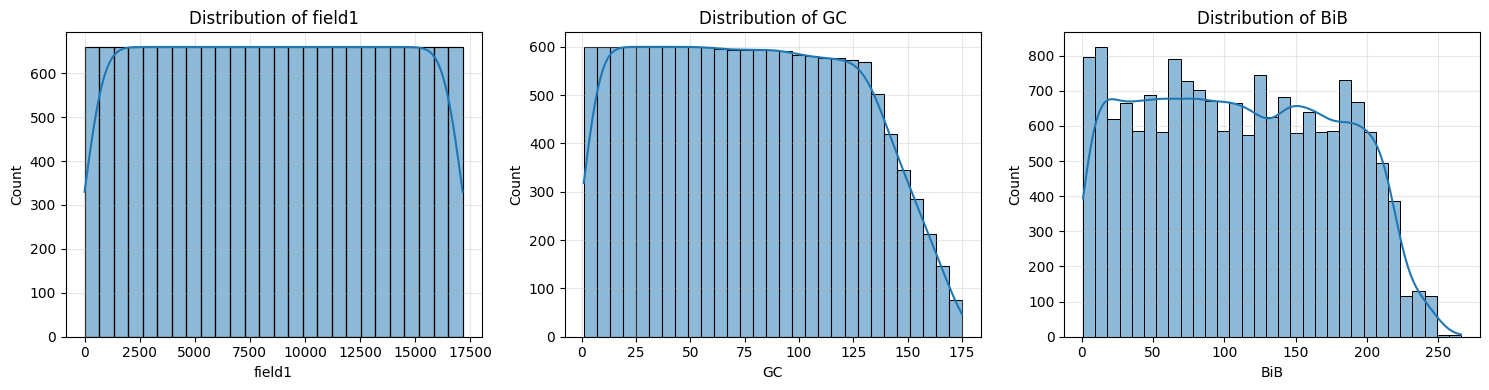

In [5]:
# Visualization 1: Distribution of numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(1, min(3, len(numeric_cols)), figsize=(15, 4))
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols[:3]):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

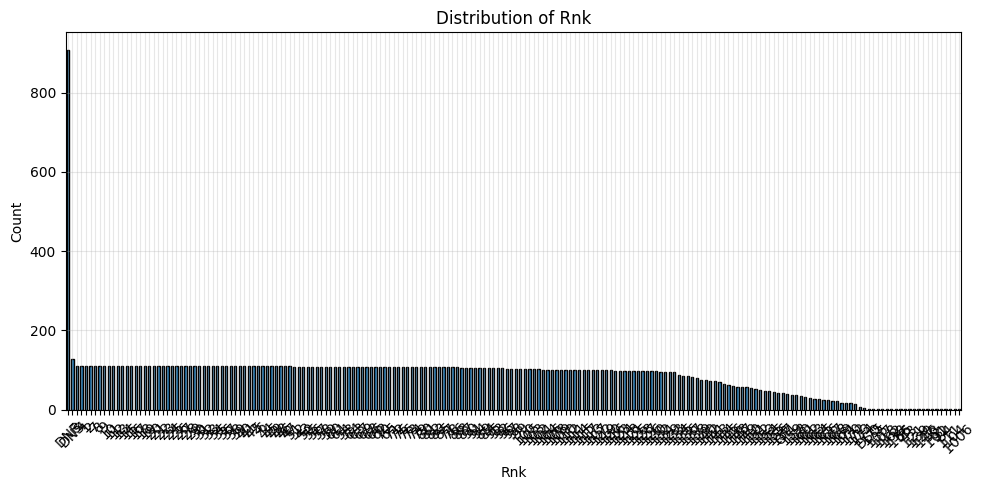

In [6]:
# Visualization 2: Categorical data distribution (if any)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    col = categorical_cols[0]
    plt.figure(figsize=(10, 5))
    df[col].value_counts().plot(kind='bar', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found")

Sampling 1000 rows from 17153 total rows for performance


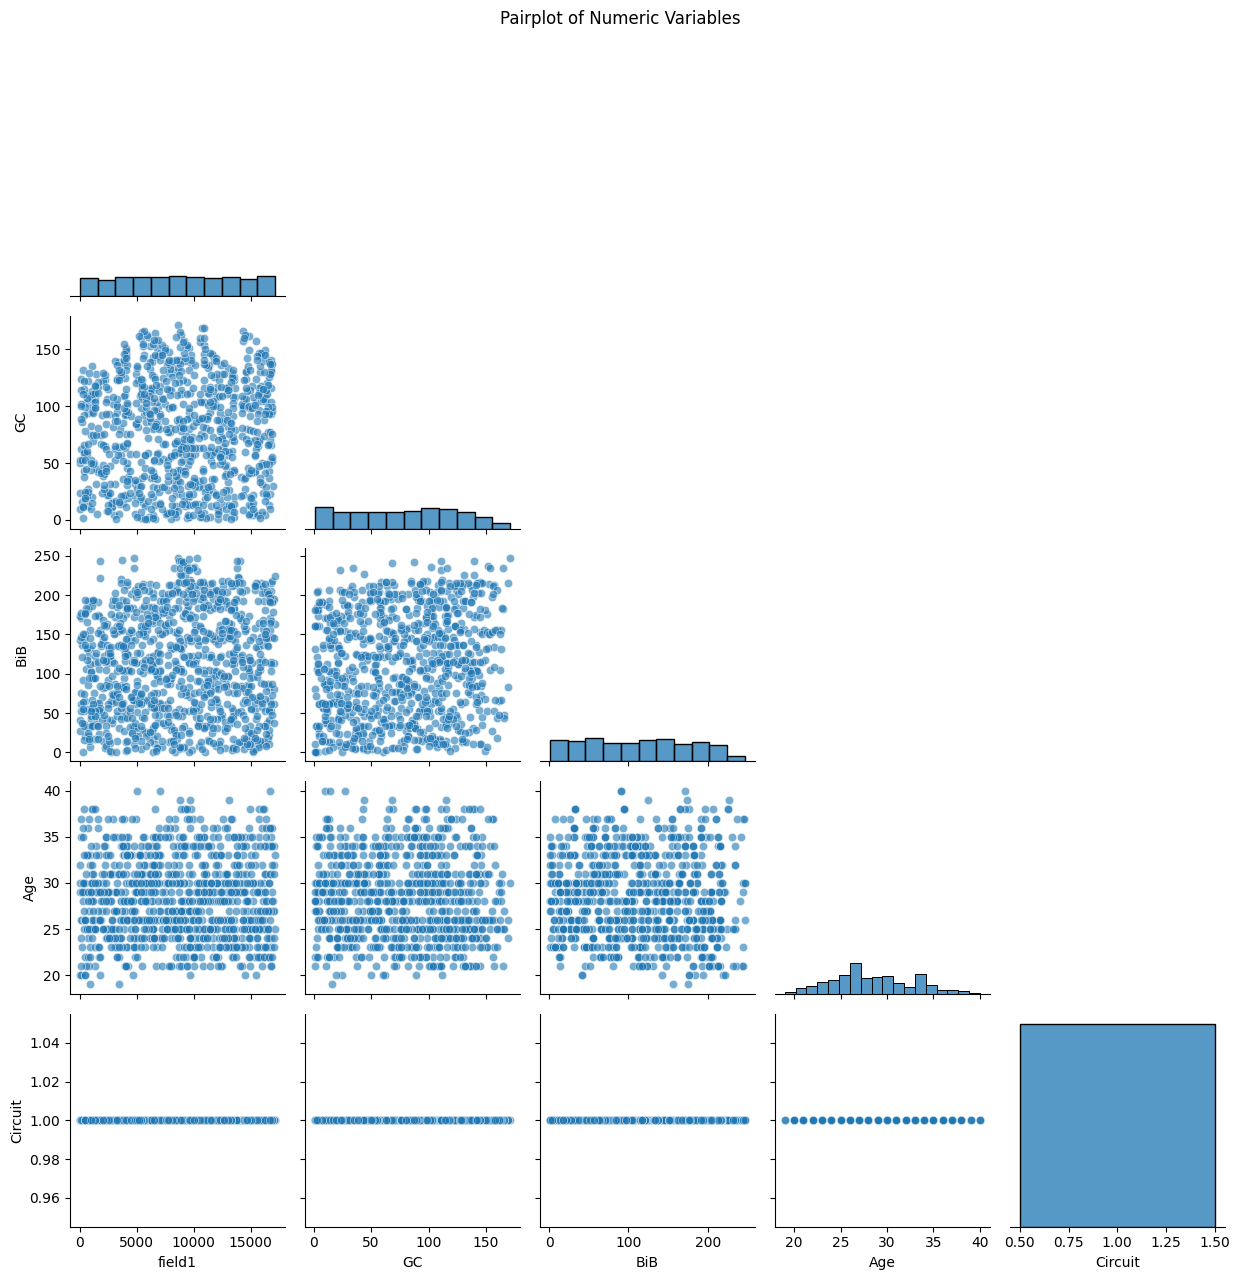

In [7]:
# Visualization 3: Pairplot (relationships between variables)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

if len(numeric_df.columns) >= 2:
    # Limit to first 5 numeric columns and sample data if dataset is large
    cols_to_plot = numeric_df.columns[:5]
    
    if len(df) > 1000:
        # Sample 1000 rows if dataset is too large
        sample_df = numeric_df[cols_to_plot].sample(n=1000, random_state=42)
        print(f"Sampling 1000 rows from {len(df)} total rows for performance")
    else:
        sample_df = numeric_df[cols_to_plot]
    
    sns.pairplot(sample_df, corner=True, diag_kind='hist', plot_kws={'alpha': 0.6})
    plt.suptitle('Pairplot of Numeric Variables', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for pairplot")

RANKING ANALYSIS


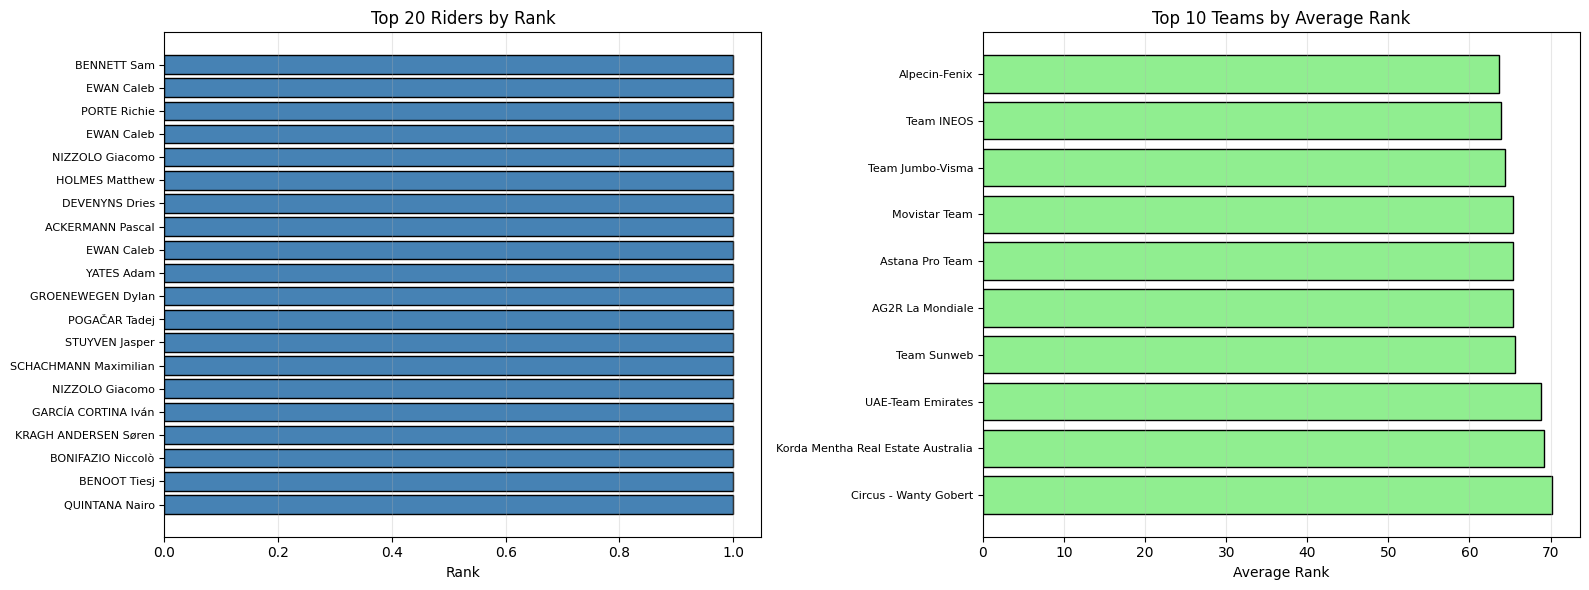


Ranking Summary:
Total riders: 16056
Best rank: 1.0
Worst rank: 175.0

Top 5 Riders:
     Rnk            Rider                     Team  Age Pnt
0    1.0      BENNETT Sam  Deceuninck - Quick Step   29  50
140  1.0       EWAN Caleb             Lotto Soudal   25  50
279  1.0     PORTE Richie         Trek - Segafredo   34  50
418  1.0       EWAN Caleb             Lotto Soudal   25  50
555  1.0  NIZZOLO Giacomo          NTT Pro Cycling   30  50


In [8]:
# Visualization 5: Ranking Analysis
print("="*70)
print("RANKING ANALYSIS")
print("="*70)

# Convert Rnk to numeric
df['Rnk'] = pd.to_numeric(df['Rnk'], errors='coerce')

# Create 2 ranking visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Top 20 Riders by Rank
top_20 = df.nsmallest(20, 'Rnk')
axes[0].barh(range(len(top_20)), top_20['Rnk'], color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20['Rider'], fontsize=8)
axes[0].set_xlabel('Rank')
axes[0].set_title('Top 20 Riders by Rank')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# 2. Top 10 Teams by Average Rank
if 'Team' in df.columns:
    team_ranks = df.groupby('Team')['Rnk'].agg(['mean', 'count']).reset_index()
    team_ranks = team_ranks[team_ranks['count'] >= 5]  # Teams with at least 5 riders
    top_teams = team_ranks.nsmallest(10, 'mean')
    
    axes[1].barh(range(len(top_teams)), top_teams['mean'], color='lightgreen', edgecolor='black')
    axes[1].set_yticks(range(len(top_teams)))
    axes[1].set_yticklabels(top_teams['Team'], fontsize=8)
    axes[1].set_xlabel('Average Rank')
    axes[1].set_title('Top 10 Teams by Average Rank')
    axes[1].invert_yaxis()
    axes[1].grid(alpha=0.3, axis='x')
else:
    axes[1].text(0.5, 0.5, 'Team data not available', 
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

# Print ranking statistics
print("\nRanking Summary:")
print(f"Total riders: {df['Rnk'].notna().sum()}")
print(f"Best rank: {df['Rnk'].min()}")
print(f"Worst rank: {df['Rnk'].max()}")
print(f"\nTop 5 Riders:")
print(df.nsmallest(5, 'Rnk')[['Rnk', 'Rider', 'Team', 'Age', 'Pnt']])